# 06 — Maintenance Policy Analysis

Goal: test whether uncertainty-aware decisions reduce dangerous missed maintenance cases.

This notebook connects your ML model to the research question:

**Can uncertainty-aware RUL models improve maintenance decisions under asymmetric risk?**


In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
from src.evaluation.policy import (
    build_policy_frame,
    compare_policies,
    sweep_maintenance_thresholds,
    sweep_cost_ratios,
)
from src.visualization.plots import plot_policy_sweep, plot_cost_ratio_sweep


## Load uncertainty results

Run notebook 05 first. If the CSV does not exist, run `scripts/run_uncertainty_policy.py` from the project root.


In [12]:
results_path = PROCESSED_DIR / "fd001_uncertainty_results.csv"
results_df = pd.read_csv(results_path)
results_df.head()


,unit,cycle,RUL,pred_mean,pred_std,error,abs_error,overestimate
0,1,1,140,128.62,18.834426,11.38,11.38,False
1,1,2,140,123.00,21.881499,17.00,17.00,False
2,1,3,140,134.08,13.245135,5.92,5.92,False
3,1,4,140,132.73,13.372251,7.27,7.27,False
4,1,5,140,133.18,13.416691,6.82,6.82,False


## Point policy vs uncertainty-aware policy

Decision convention: `True = maintain now`.

- Point policy: maintain if predicted RUL ≤ threshold.
- Uncertainty-aware policy: maintain if conservative RUL ≤ threshold.
- Conservative RUL = predicted mean − k × uncertainty.


In [13]:
MAINTENANCE_THRESHOLD = 20
K = 1.64
COST_FP = 1
COST_FN = 5

policy_df = build_policy_frame(
    results_df,
    maintenance_threshold=MAINTENANCE_THRESHOLD,
    k=K,
)
policy_df[["actual_rul", "predicted_rul", "uncertainty_std", "conservative_rul", "decision_point_policy", "decision_uncertainty_policy"]].head()


,actual_rul,predicted_rul,uncertainty_std,conservative_rul,decision_point_policy,decision_uncertainty_policy
0,140,128.62,18.834426,97.731541,False,False
1,140,123.00,21.881499,87.114342,False,False
2,140,134.08,13.245135,112.357979,False,False
3,140,132.73,13.372251,110.799508,False,False
4,140,133.18,13.416691,111.176627,False,False


In [14]:
policy_metrics, policy_costs = compare_policies(
    policy_df,
    cost_fp=COST_FP,
    cost_fn=COST_FN,
)

display(policy_metrics)
display(policy_costs)


,policy,TP_maintained_risky,FP_unnecessary_maintenance,TN_correct_no_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate
0,decision_point_policy,346,20,3630,74,0.17619,0.005479
1,decision_uncertainty_policy,420,490,3160,0,0.00000,0.134247


,policy,FP_unnecessary_maintenance,FN_missed_risky_cases,total_cost,average_cost_per_sample
0,decision_point_policy,20,74,390.0,0.095823
1,decision_uncertainty_policy,490,0,490.0,0.120393


## Threshold sweep

We test whether the conclusion is stable across different maintenance thresholds.


In [15]:
threshold_df = sweep_maintenance_thresholds(
    results_df,
    thresholds=range(10, 61, 5),
    k=K,
    cost_fp=COST_FP,
    cost_fn=COST_FN,
)
threshold_df.head()


,threshold,policy,fn_rate,fp_rate,cost,fn_count,fp_count
0,10,Point Prediction,0.259091,0.002078,0.071990,57,8
1,10,Uncertainty-Aware,0.000000,0.057922,0.054791,0,223
2,15,Point Prediction,0.209375,0.005600,0.087469,67,21
3,15,Uncertainty-Aware,0.003125,0.103200,0.096314,1,387
4,20,Point Prediction,0.176190,0.005479,0.095823,74,20


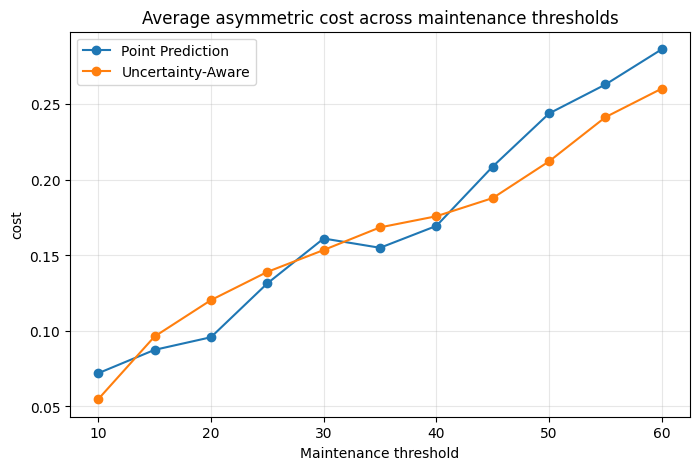

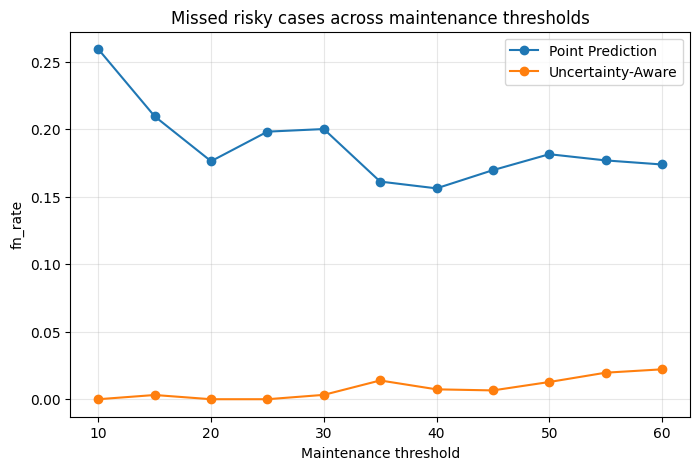

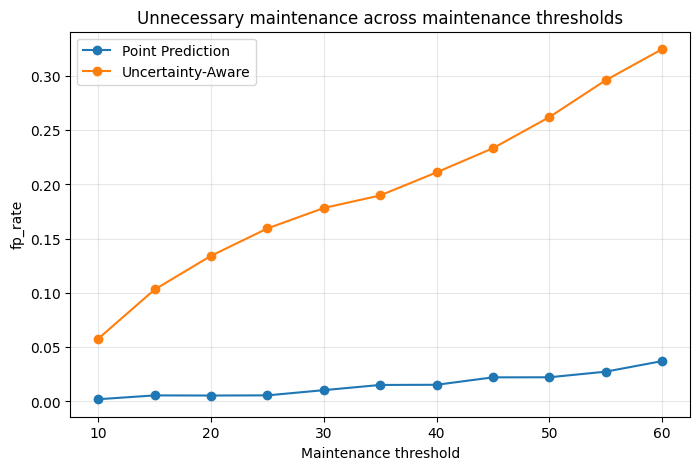

In [16]:
plot_policy_sweep(threshold_df, y_col="cost", title="Average asymmetric cost across maintenance thresholds")
plt.show()

plot_policy_sweep(threshold_df, y_col="fn_rate", title="Missed risky cases across maintenance thresholds")
plt.show()

plot_policy_sweep(threshold_df, y_col="fp_rate", title="Unnecessary maintenance across maintenance thresholds")
plt.show()


## Failure-cost sensitivity

Here we increase the cost of missing a risky engine. This checks whether uncertainty-aware decisions become more valuable when false negatives are expensive.


In [17]:
cost_ratio_df = sweep_cost_ratios(
    results_df,
    fixed_threshold=20,
    cost_ratios=[5, 10, 20, 50, 100],
    k=K,
    cost_fp=1,
)
cost_ratio_df


,failure_cost,policy,fn_rate,fp_rate,cost,fn_count,fp_count
0,5,Point Prediction,0.17619,0.005479,0.095823,74,20
1,5,Uncertainty-Aware,0.00000,0.134247,0.120393,0,490
2,10,Point Prediction,0.17619,0.005479,0.186732,74,20
3,10,Uncertainty-Aware,0.00000,0.134247,0.120393,0,490
4,20,Point Prediction,0.17619,0.005479,0.368550,74,20
5,20,Uncertainty-Aware,0.00000,0.134247,0.120393,0,490
6,50,Point Prediction,0.17619,0.005479,0.914005,74,20
7,50,Uncertainty-Aware,0.00000,0.134247,0.120393,0,490
8,100,Point Prediction,0.17619,0.005479,1.823096,74,20
9,100,Uncertainty-Aware,0.00000,0.134247,0.120393,0,490


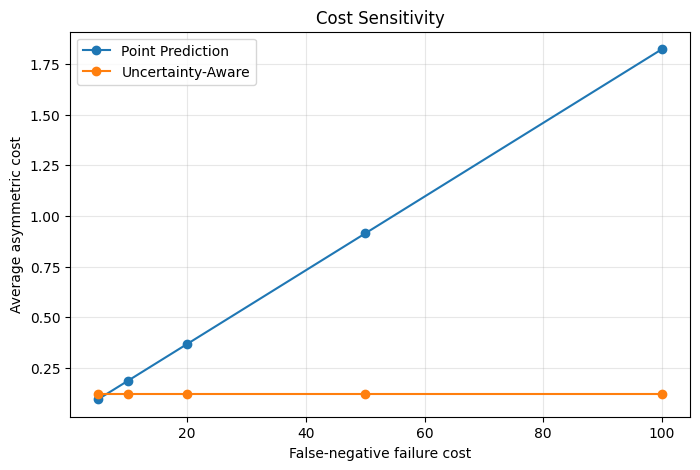

In [18]:
plot_cost_ratio_sweep(cost_ratio_df)
plt.show()


## Report conclusion template



> The uncertainty-aware policy reduces missed risky cases by maintaining earlier when predictive uncertainty is high. This increases false positives, meaning more unnecessary maintenance, but under asymmetric risk this trade-off can be favorable when missed failures are much costlier than early maintenance.


In [19]:
from src.evaluation.policy import sweep_k_values

k_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.64, 2.0]

k_sweep_df = sweep_k_values(
    actual_rul=policy_df["actual_rul"],
    predicted_rul=policy_df["predicted_rul"],
    uncertainty_std=policy_df["uncertainty_std"],
    k_values=k_values,
    maintenance_threshold=20,
    cost_fp=1.0,
    cost_fn=5.0,
)

k_sweep_df

,k,TP_maintained_risky,FP_unnecessary_maintenance,TN_correct_no_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate,total_cost,average_cost_per_sample
0,0.00,346,20,3630,74,0.176190,0.005479,390.0,0.095823
1,0.25,363,32,3618,57,0.135714,0.008767,317.0,0.077887
2,0.50,378,48,3602,42,0.100000,0.013151,258.0,0.063391
3,0.75,393,77,3573,27,0.064286,0.021096,212.0,0.052088
4,1.00,404,155,3495,16,0.038095,0.042466,235.0,0.057740
5,1.25,416,259,3391,4,0.009524,0.070959,279.0,0.068550
6,1.50,419,392,3258,1,0.002381,0.107397,397.0,0.097543
7,1.64,420,490,3160,0,0.000000,0.134247,490.0,0.120393
8,2.00,420,759,2891,0,0.000000,0.207945,759.0,0.186486


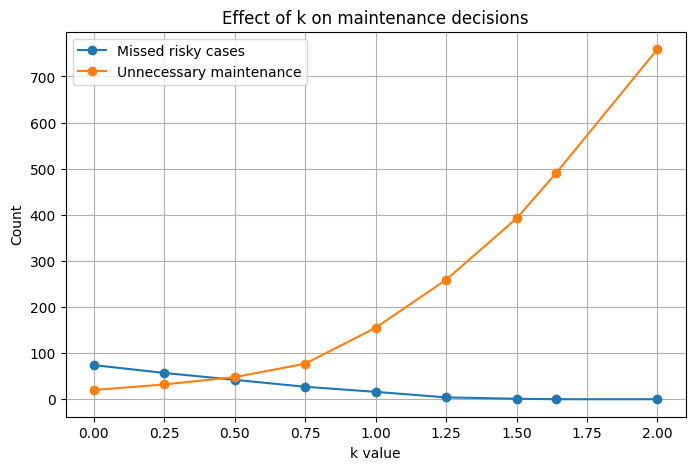

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_sweep_df["k"], k_sweep_df["FN_missed_risky_cases"], marker="o", label="Missed risky cases")
plt.plot(k_sweep_df["k"], k_sweep_df["FP_unnecessary_maintenance"], marker="o", label="Unnecessary maintenance")
plt.xlabel("k value")
plt.ylabel("Count")
plt.title("Effect of k on maintenance decisions")
plt.legend()
plt.grid(True)
plt.show()

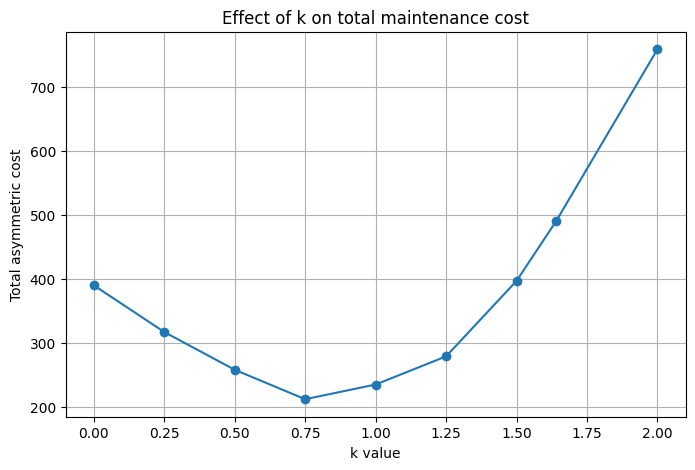

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(k_sweep_df["k"], k_sweep_df["total_cost"], marker="o")
plt.xlabel("k value")
plt.ylabel("Total asymmetric cost")
plt.title("Effect of k on total maintenance cost")
plt.grid(True)
plt.show()

In [22]:
threshold_df.to_csv(PROCESSED_DIR / "threshold_sensitivity_results.csv", index=False)
cost_ratio_df.to_csv(PROCESSED_DIR / "cost_ratio_sensitivity_results.csv", index=False)
policy_metrics.to_csv(PROCESSED_DIR / "policy_metrics.csv", index=False)
policy_costs.to_csv(PROCESSED_DIR / "policy_costs.csv", index=False)
k_sweep_df.to_csv(PROCESSED_DIR / "k_sweep_results.csv", index=False)
print("Saved policy analysis tables")


Saved policy analysis tables


In [23]:
from src.evaluation.policy import sweep_k_values
from src.config import PROCESSED_DIR
import pandas as pd

k_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.64, 2.0]
cost_fn_values = [2, 5, 10, 20, 50, 100]

all_k_sweeps = []

for cost_fn in cost_fn_values:
    temp_df = sweep_k_values(
        actual_rul=policy_df["actual_rul"],
        predicted_rul=policy_df["predicted_rul"],
        uncertainty_std=policy_df["uncertainty_std"],
        k_values=k_values,
        maintenance_threshold=20,
        cost_fp=1.0,
        cost_fn=cost_fn,
    )
    
    temp_df["cost_fp"] = 1.0
    temp_df["cost_fn"] = cost_fn
    all_k_sweeps.append(temp_df)

k_cost_sweep_df = pd.concat(all_k_sweeps, ignore_index=True)

k_cost_sweep_df.to_csv(
    PROCESSED_DIR / "k_cost_ratio_sweep_results.csv",
    index=False
)

k_cost_sweep_df

,k,TP_maintained_risky,FP_unnecessary_maintenance,TN_correct_no_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate,total_cost,average_cost_per_sample,cost_fp,cost_fn
0,0.00,346,20,3630,74,0.176190,0.005479,168.0,0.041278,1.0,2
1,0.25,363,32,3618,57,0.135714,0.008767,146.0,0.035872,1.0,2
2,0.50,378,48,3602,42,0.100000,0.013151,132.0,0.032432,1.0,2
3,0.75,393,77,3573,27,0.064286,0.021096,131.0,0.032187,1.0,2
4,1.00,404,155,3495,16,0.038095,0.042466,187.0,0.045946,1.0,2
5,1.25,416,259,3391,4,0.009524,0.070959,267.0,0.065602,1.0,2
6,1.50,419,392,3258,1,0.002381,0.107397,394.0,0.096806,1.0,2
7,1.64,420,490,3160,0,0.000000,0.134247,490.0,0.120393,1.0,2
8,2.00,420,759,2891,0,0.000000,0.207945,759.0,0.186486,1.0,2
9,0.00,346,20,3630,74,0.176190,0.005479,390.0,0.095823,1.0,5


In [24]:
best_k_by_cost = (
    k_cost_sweep_df
    .loc[k_cost_sweep_df.groupby("cost_fn")["total_cost"].idxmin()]
    .sort_values("cost_fn")
)

best_k_by_cost

,k,TP_maintained_risky,FP_unnecessary_maintenance,TN_correct_no_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate,total_cost,average_cost_per_sample,cost_fp,cost_fn
3,0.75,393,77,3573,27,0.064286,0.021096,131.0,0.032187,1.0,2
12,0.75,393,77,3573,27,0.064286,0.021096,212.0,0.052088,1.0,5
23,1.25,416,259,3391,4,0.009524,0.070959,299.0,0.073464,1.0,10
32,1.25,416,259,3391,4,0.009524,0.070959,339.0,0.083292,1.0,20
42,1.50,419,392,3258,1,0.002381,0.107397,442.0,0.108600,1.0,50
52,1.64,420,490,3160,0,0.000000,0.134247,490.0,0.120393,1.0,100


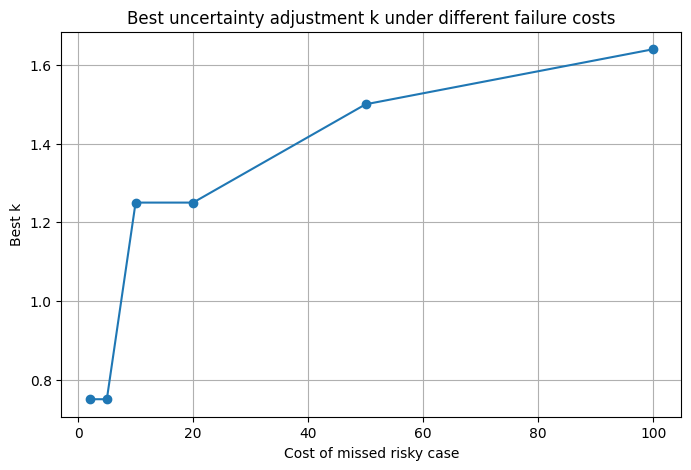

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(best_k_by_cost["cost_fn"], best_k_by_cost["k"], marker="o")
plt.xlabel("Cost of missed risky case")
plt.ylabel("Best k")
plt.title("Best uncertainty adjustment k under different failure costs")
plt.grid(True)
plt.show()

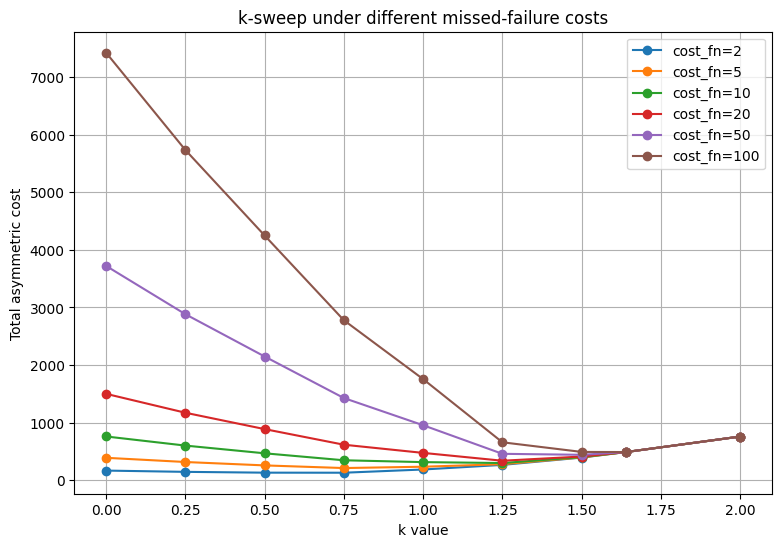

In [26]:
plt.figure(figsize=(9, 6))

for cost_fn in cost_fn_values:
    subset = k_cost_sweep_df[k_cost_sweep_df["cost_fn"] == cost_fn]
    plt.plot(subset["k"], subset["total_cost"], marker="o", label=f"cost_fn={cost_fn}")

plt.xlabel("k value")
plt.ylabel("Total asymmetric cost")
plt.title("k-sweep under different missed-failure costs")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
best_k_by_cost[
    [
        "cost_fn",
        "k",
        "TP_maintained_risky",
        "FP_unnecessary_maintenance",
        "FN_missed_risky_cases",
        "false_negative_rate",
        "false_positive_rate",
        "total_cost",
    ]
]

,cost_fn,k,TP_maintained_risky,FP_unnecessary_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate,total_cost
3,2,0.75,393,77,27,0.064286,0.021096,131.0
12,5,0.75,393,77,27,0.064286,0.021096,212.0
23,10,1.25,416,259,4,0.009524,0.070959,299.0
32,20,1.25,416,259,4,0.009524,0.070959,339.0
42,50,1.50,419,392,1,0.002381,0.107397,442.0
52,100,1.64,420,490,0,0.000000,0.134247,490.0


In [28]:

from src.evaluation.policy import sweep_k_values
from src.config import PROCESSED_DIR

k_values_fine = np.round(np.arange(0.0, 2.01, 0.05), 2)
cost_fn_values = [2, 5, 10, 20, 50, 100]

fine_sweep_results = []

for cost_fn in cost_fn_values:
    temp_df = sweep_k_values(
        actual_rul=policy_df["actual_rul"],
        predicted_rul=policy_df["predicted_rul"],
        uncertainty_std=policy_df["uncertainty_std"],
        k_values=k_values_fine,
        maintenance_threshold=20,
        cost_fp=1.0,
        cost_fn=cost_fn,
    )
    temp_df["cost_fp"] = 1.0
    temp_df["cost_fn"] = cost_fn
    fine_sweep_results.append(temp_df)

fine_k_cost_sweep_df = pd.concat(fine_sweep_results, ignore_index=True)

best_fine_k_by_cost = (
    fine_k_cost_sweep_df
    .loc[fine_k_cost_sweep_df.groupby("cost_fn")["total_cost"].idxmin()]
    .sort_values("cost_fn")
)

fine_k_cost_sweep_df.to_csv(PROCESSED_DIR / "fine_k_cost_ratio_sweep_results.csv", index=False)
best_fine_k_by_cost.to_csv(PROCESSED_DIR / "best_fine_k_by_cost.csv", index=False)

best_fine_k_by_cost[
    [
        "cost_fn",
        "k",
        "TP_maintained_risky",
        "FP_unnecessary_maintenance",
        "FN_missed_risky_cases",
        "false_negative_rate",
        "false_positive_rate",
        "total_cost",
    ]
]

,cost_fn,k,TP_maintained_risky,FP_unnecessary_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate,total_cost
13,2,0.65,386,59,34,0.080952,0.016164,127.0
56,5,0.75,393,77,27,0.064286,0.021096,212.0
106,10,1.20,413,229,7,0.016667,0.062740,299.0
149,20,1.30,418,280,2,0.004762,0.076712,320.0
191,50,1.35,419,311,1,0.002381,0.085205,361.0
232,100,1.35,419,311,1,0.002381,0.085205,411.0


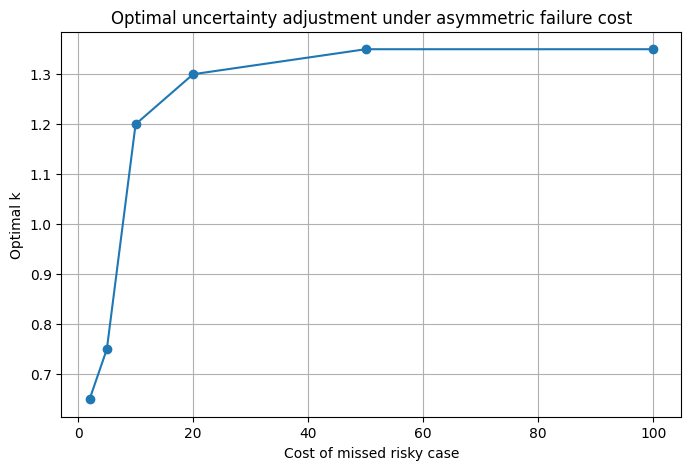

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(best_fine_k_by_cost["cost_fn"], best_fine_k_by_cost["k"], marker="o")
plt.xlabel("Cost of missed risky case")
plt.ylabel("Optimal k")
plt.title("Optimal uncertainty adjustment under asymmetric failure cost")
plt.grid(True)
plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR

best_all = pd.read_csv(PROCESSED_DIR / "all_datasets_best_k_by_cost.csv")

best_all[
    [
        "dataset",
        "cost_fn",
        "k",
        "FP_unnecessary_maintenance",
        "FN_missed_risky_cases",
        "false_negative_rate",
        "false_positive_rate",
        "total_cost",
    ]
]

,dataset,cost_fn,k,FP_unnecessary_maintenance,FN_missed_risky_cases,false_negative_rate,false_positive_rate,total_cost
0,FD001,2,0.45,42,44,0.104762,0.011507,130.0
1,FD001,5,0.80,93,26,0.061905,0.025479,223.0
2,FD001,10,1.25,252,4,0.009524,0.069041,292.0
3,FD001,20,1.25,252,4,0.009524,0.069041,332.0
4,FD001,50,1.40,343,1,0.002381,0.093973,393.0
5,FD001,100,1.55,438,0,0.000000,0.120000,438.0
6,FD002,2,0.65,476,257,0.235348,0.051722,990.0
7,FD002,5,1.00,859,129,0.118132,0.093339,1504.0
8,FD002,10,1.15,1094,93,0.085165,0.118874,2024.0
9,FD002,20,1.40,1558,57,0.052198,0.169293,2698.0


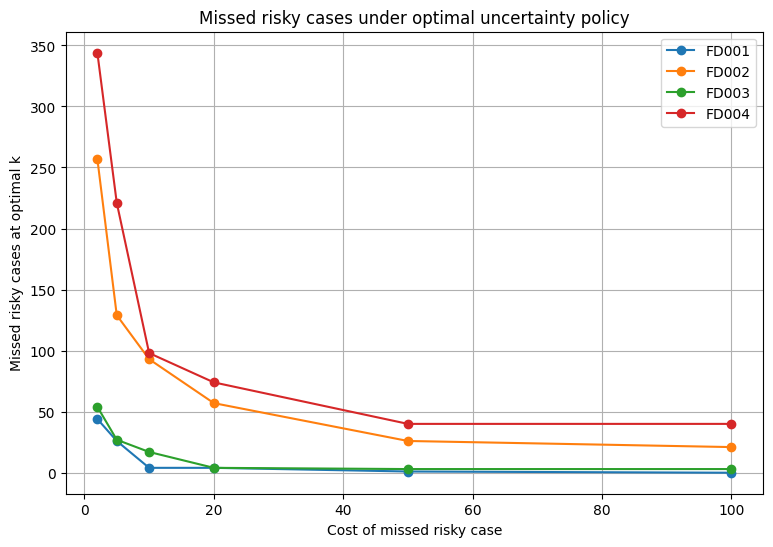

In [31]:
plt.figure(figsize=(9, 6))

for dataset in best_all["dataset"].unique():
    subset = best_all[best_all["dataset"] == dataset]
    plt.plot(
        subset["cost_fn"],
        subset["FN_missed_risky_cases"],
        marker="o",
        label=dataset,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Missed risky cases at optimal k")
plt.title("Missed risky cases under optimal uncertainty policy")
plt.legend()
plt.grid(True)
plt.show()